In [17]:
# pandas for data manipulation
# re for regular expressions
import re

# pyplot for plotting
# numpy for numerical operations
import numpy as np
import pandas as pd
from scipy.signal import stft
from sklearn.decomposition import PCA

# other .py files
from utils.csv_import import get_csv_files_generalistic, sort_meta_info

In [18]:
# Retrieve CSV files

path_to: str = "C:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project"
path: str = path_to + "\\new_data"

FileMap = dict[str, dict[str, str]]
csi_map = dict[str, dict[str, dict[str, np.ndarray]]]


data_files = get_csv_files_generalistic(path)
users_id, activities_id, places_id, esps_id = sort_meta_info(path)
print(f"Users: {users_id}")
print(f"Activities: {activities_id}")
print(f"Cenário: {places_id}")
print(f"ESPs: {esps_id}")

Users: ['00', '01']
Activities: ['00']
Cenário: ['01']
ESPs: ['02', '03']


In [19]:
# Per-packet normalization to mitigate AGC effects.
# magnitude shape: (n_samples, n_subcarriers)

# antes de sacar o AGC (5 GHz)
def calibrate_magnitude(magnitude: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(magnitude, axis=1, keepdims=True)
    norm[norm == 0] = 1  # avoid division by zero
    return magnitude / norm


def apply_pca(magnitude_data, variance_ratio=0.999):
	pca = PCA(n_components=variance_ratio)
	transformed = pca.fit_transform(magnitude_data)
	return transformed, pca


def process_csi(data_file: str) -> np.ndarray:

	file_csv = pd.read_csv(data_file, header=None)

	# number of samples
	csi_raw: pd.Series = file_csv.iloc[:, 25]

	total_sc: int = 128
	valid_csi: list[list[float]] = []

    # contar CSI inválidos
	no_match_count: int = 0
	no_complete_count: int = 0

	for entry in csi_raw:
		match = re.search(r"\[(.*?)\]", str(entry))
		if not match:
			no_match_count += 1
			continue

		nums = [float(n) for n in re.findall(r"-?\d+", match.group(1))]

		if len(nums) == total_sc:
			valid_csi.append(nums)
		else:
			no_complete_count += 1

	valid_csi = np.array(valid_csi)

    # (n_amostras, 128)
	complex_csi = valid_csi[:, ::2] + 1j * valid_csi[:, 1::2]

    # coloca sc DC no centro (index 32)
	fft_csi = np.fft.fftshift(complex_csi, axes=1)

    # Extract the 52 active subcarriers (IEEE 802.11n standard): [6:58]
    # (n_amostras, 52)
	active_sc = fft_csi[:, 6:58]

    # Remove subcarriers at positions 25, 26, 27 (center)
    # (n_amostras, 49)
	active_sc = np.delete(active_sc, [25, 26, 27], axis=1)

    # seleciona sub_carriers: 2 a 47
	active_sc = active_sc[:, 2:48]

	magnitude = np.abs(active_sc)
	magnitude = calibrate_magnitude(magnitude)
	pca_features, _ = apply_pca(magnitude, variance_ratio=0.999)

	return pca_features


def process_magnitude(data_files: FileMap) -> csi_map:

	magnitudes = {}

	for user_key, activities_map in data_files.items():
		magnitudes[user_key] = {}

		for activity, places_map in activities_map.items():
			magnitudes[user_key][activity] = {}

			for place, esps_map in places_map.items():
				magnitudes[user_key][activity][place] = {}

				for esp, file_path in esps_map.items():
					if file_path is not None:
						path = file_path[0] if isinstance(file_path, list) else file_path
						magnitudes[user_key][activity][place][esp] = process_csi(str(path))

	return magnitudes

In [20]:
def compute_pca1_variance(pca_features: np.ndarray) -> float:
    pca1 = pca_features[:, 0]
    return np.var(pca1)


def compute_doppler_energy(pca_features: np.ndarray, fs: float = 1000.0):
    """Fs = sampling rate (Hz)
    """
    pca1 = pca_features[:, 0]

    # Remove mean (remove static component)
    pca1 = pca1 - np.mean(pca1)

    f, t, Zxx = stft(pca1, fs=fs, nperseg=256)

    # Remove DC component (f=0)
    non_zero_idx = f > 0.1

    energy = np.sum(np.abs(Zxx[non_zero_idx, :])**2)

    return energy


def compute_snr_proxy(pca_features: np.ndarray, fs: float = 1000.0):
    pca1 = pca_features[:, 0]
    pca1 = pca1 - np.mean(pca1)

    f, t, Zxx = stft(pca1, fs=fs, nperseg=256)

    power_spectrum = np.abs(Zxx)**2

    # Static band (near DC)
    static_idx = f < 0.1

    # Dynamic band
    dynamic_idx = (f >= 0.1) & (f <= 10)

    static_power = np.sum(power_spectrum[static_idx, :])
    dynamic_power = np.sum(power_spectrum[dynamic_idx, :])

    if static_power == 0:
        return 0

    return dynamic_power / static_power

In [ ]:
magnitude_data = process_magnitude(data_files)


# Flatten the nested dict into a list of (n_samples, n_components) arrays
all_features = [
    features
    for activities_map in magnitude_data.values()
    for places_map in activities_map.values()
    for esps_map in places_map.values()
    for features in esps_map.values()
]

# Each file may produce a different number of PCA components; truncate to the minimum
min_components = min(f.shape[1] for f in all_features)
for f in all_features:
    print(f"Original shape: {f.shape}, truncated to {min_components} components")
all_features = [f[:, :min_components] for f in all_features]

pca_features = np.concatenate(all_features, axis=0)
print(f"pca_features shape: {pca_features.shape}  (min_components={min_components})")

Original shape: (139, 24), truncated to 24 components
Original shape: (161, 30), truncated to 24 components
Original shape: (351, 31), truncated to 24 components
pca_features shape: (651, 24)  (min_components=24)


In [22]:
# define sampling frequency (Hz) as
# the original packet rate/s
fs = 1000

# Compute metrics for each individual CSI file
metrics_per_file = {}

scenarios = {
    "11": "Cenário 1 - 2.4 GHz",
    "12": "Cenário 1 - 5 GHz",
    "21": "Cenário 2 - 2.4 GHz",
	"22": "Cenário 2 - 5 GHz",
}

for user_key, activities_map in magnitude_data.items():
    for activity, places_map in activities_map.items():
        for place, esps_map in places_map.items():
            for esp, features in esps_map.items():
                label = f"{user_key}-{activity}-{place}-{esp}"
                metrics_per_file[label] = {
                    "PCA1 Variance": compute_pca1_variance(features),
                    "Doppler Energy": compute_doppler_energy(features, fs),
                    "SNR Proxy": compute_snr_proxy(features, fs),
                }

print(f"Computed metrics for {len(metrics_per_file)} files")


Computed metrics for 3 files


c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 139, using nperseg = 139
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,
c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 161, using nperseg = 161
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,


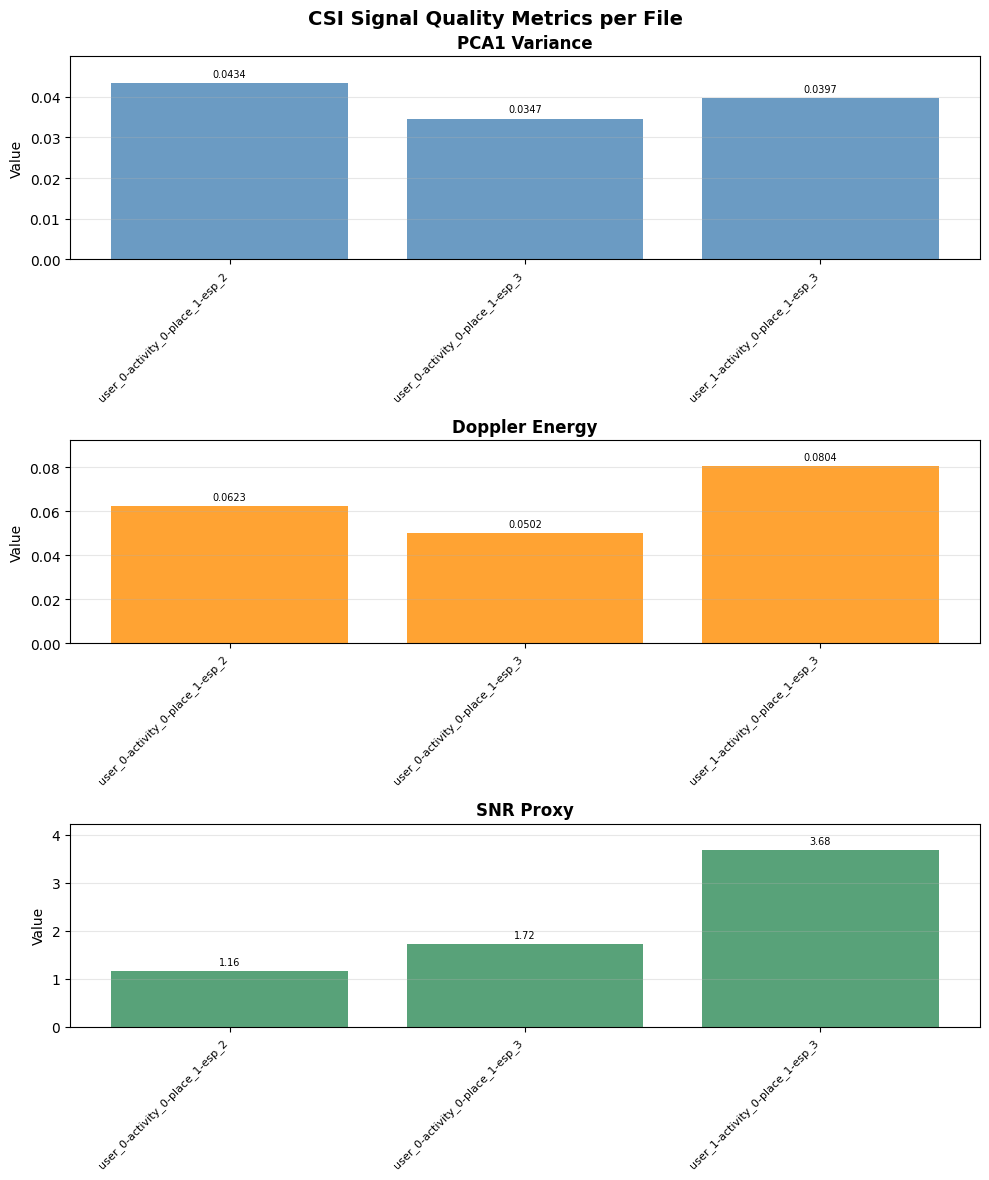

In [23]:
metric_names = ["PCA1 Variance", "Doppler Energy", "SNR Proxy"]
colors = ["steelblue", "darkorange", "seagreen"]
labels = list(metrics_per_file.keys())
x = np.arange(len(labels))

fig, axes = plt.subplots(3, 1, figsize=(max(10, len(labels) * 0.8), 12))

for ax, metric, color in zip(axes, metric_names, colors):
    values = [metrics_per_file[lbl][metric] for lbl in labels]
    bars = ax.bar(x, values, color=color, alpha=0.8)
    ax.bar_label(bars, fmt="%.3g", padding=3, fontsize=7)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylabel("Value")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.margins(y=0.15)

fig.suptitle("CSI Signal Quality Metrics per File", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


#### CSI Magnitude vs Number of Packages analysis

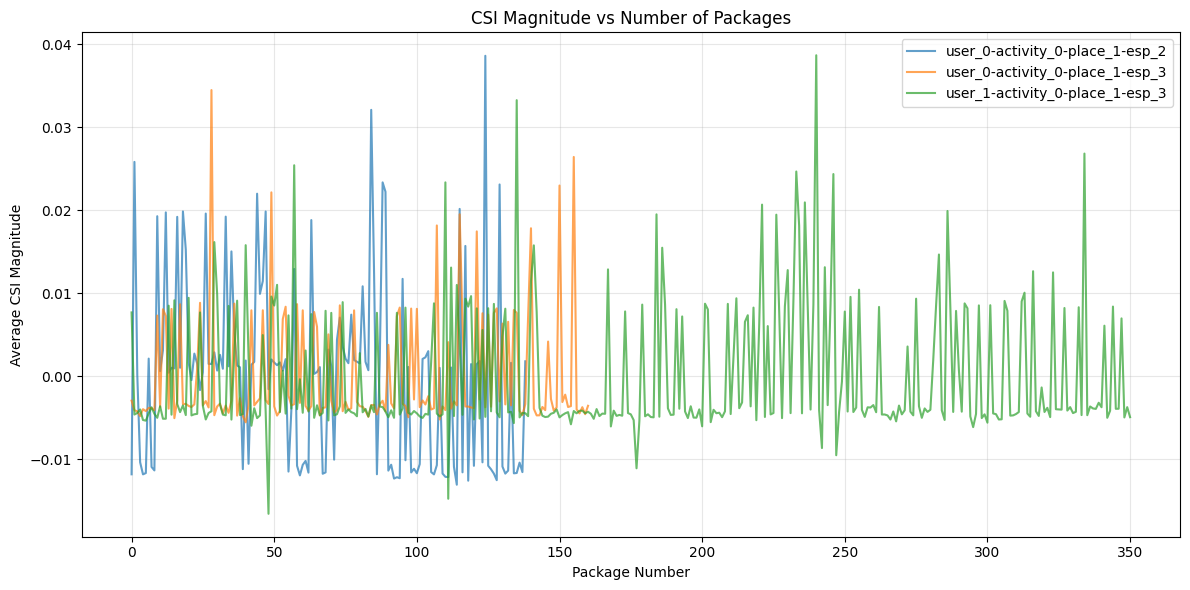

In [24]:
plt.figure(figsize=(12, 6))

for user_key, activities_map in magnitude_data.items():
	for activity, places_map in activities_map.items():
		for place, esps_map in places_map.items():
			for esp, csi_magnitude in esps_map.items():
				# Calculate average magnitude across all subcarriers for each packet
				avg_magnitude = csi_magnitude.mean(axis=1)
				n_packets = len(avg_magnitude)

				plt.plot(range(n_packets), avg_magnitude, label=f'{user_key}-{activity}-{place}-{esp}', alpha=0.7)

plt.xlabel('Package Number')
plt.ylabel('Average CSI Magnitude')
plt.title('CSI Magnitude vs Number of Packages')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

# Create datasets for each scenario
scenario_datasets = {}

for scenario_key, scenario_name in scenarios.items():
	print(f"\nProcessing {scenario_name}...")

	features_list = []
	labels_list = []

	# Iterate through all data
	for user_key, activities_map in magnitude_data.items():
		for activity, places_map in activities_map.items():
			for place, esps_map in places_map.items():
				for esp, features in esps_map.items():
					# Extract scenario from place key
					# Assuming place format contains scenario info
					# Adjust the logic based on your actual data structure

					# Determine label: 0 for empty room, 1 for walking
					# You may need to adjust this based on your activity naming
					label = 1 if 'walking' in activity.lower() else 0

					# Compute metrics for this file
					pca1_var = compute_pca1_variance(features)
					doppler_eng = compute_doppler_energy(features, fs)
					snr_prox = compute_snr_proxy(features, fs)

					# Create feature vector
					feature_vector = np.array([pca1_var, doppler_eng, snr_prox])

					features_list.append(feature_vector)
					labels_list.append(label)

	# Convert to numpy arrays
	X = np.array(features_list)
	y = np.array(labels_list)

	scenario_datasets[scenario_key] = {
		'name': scenario_name,
		'X': X,
		'y': y,
		'n_samples': len(y),
	}

	print(f"  Samples: {len(y)}, Features shape: {X.shape}")
	print(f"  Class distribution - Empty: {np.sum(y == 0)}, Walking: {np.sum(y == 1)}")

# Display summary
print("\n" + "=" * 50)
print("Dataset Summary")
print("=" * 50)
for scenario_key, dataset in scenario_datasets.items():
	print(f"{dataset['name']}: {dataset['n_samples']} samples")


Processing Cenário 1 - 2.4 GHz...
  Samples: 3, Features shape: (3, 3)
  Class distribution - Empty: 3, Walking: 0

Processing Cenário 1 - 5 GHz...
  Samples: 3, Features shape: (3, 3)
  Class distribution - Empty: 3, Walking: 0

Processing Cenário 2 - 2.4 GHz...
  Samples: 3, Features shape: (3, 3)
  Class distribution - Empty: 3, Walking: 0

Processing Cenário 2 - 5 GHz...
  Samples: 3, Features shape: (3, 3)
  Class distribution - Empty: 3, Walking: 0

Dataset Summary
Cenário 1 - 2.4 GHz: 3 samples
Cenário 1 - 5 GHz: 3 samples
Cenário 2 - 2.4 GHz: 3 samples
Cenário 2 - 5 GHz: 3 samples


c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 139, using nperseg = 139
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,
c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 161, using nperseg = 161
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,


(3, 3)